In [1]:
#先看看数据长什么样子
words=open('prenoms.txt',encoding='utf-8').read().splitlines()
words =[w for w in words if w.strip()]

print(words[:5])
print(len(words))

chars=sorted(list(set(''.join(words))))
print(len(chars),chars)

print(max(words,key=len))
print(min(words,key=len))

['MARIE', 'JEAN', 'PIERRE', 'MICHEL', 'ANDRÉ']
30000
45 ["'", '-', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'À', 'Â', 'Ä', 'Æ', 'Ç', 'È', 'É', 'Ê', 'Ë', 'Î', 'Ï', 'Ô', 'Ö', 'Ù', 'Û', 'Ü', 'Ÿ']
GUILLAUME-ALEXANDRE
GUY


In [2]:
# 把字符变成数字，再统计每个相邻字符对出现多少次
import torch

#string to int
stoi={s:i+1 for i,s in enumerate(chars)} #0留给我们人为制造开头和结尾的'.'
stoi['.']=0

# int to string
itos={i:s for s,i in stoi.items()}

V=len(stoi)
N=torch.zeros((V,V),dtype=torch.int32) #计数矩阵，类似于邻接矩阵那种

for w in words:
    chs=['.']+list(w)+['.'] #前后人为的加开始和结束的标志
    for ch1,ch2 in zip(chs,chs[1:]): #两两相邻配对
        N[stoi[ch1],stoi[ch2]]+=1

print(N)
print(f"总共有{N.sum().item()}个bigram:")

print('总和:', N.sum().item())        # 226325
print('第 0 行:', N[0])               # 应该有非零计数
print('第 0 行最大:', itos[N[0].argmax().item()], N[0].max().item())

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], dtype=torch.int32)
总共有226325个bigram:
总和: 226325
第 0 行: tensor([   0,    0,    0, 3399,  825, 1483, 1208, 1400,  864,  907, 1039,  788,
        1352, 1503, 2108, 3606, 1501,  546,  620,   32, 1142, 2539, 1185,   72,
         329,  294,   29,  661,  393,    0,    2,    0,    0,    1,    2,  161,
           0,    0,    2,    2,    0,    5,    0,    0,    0,    0],
       dtype=torch.int32)
第 0 行最大: M 3606


In [3]:
pairs = [(itos[i] + itos[j], N[i, j].item()) for i in range(46) for j in range(46)]
for bg, cnt in sorted(pairs, key=lambda x: -x[1])[:5]:
    print(cnt, bg)

7537 A.
6840 E.
6292 AN
3741 N.
3741 NE


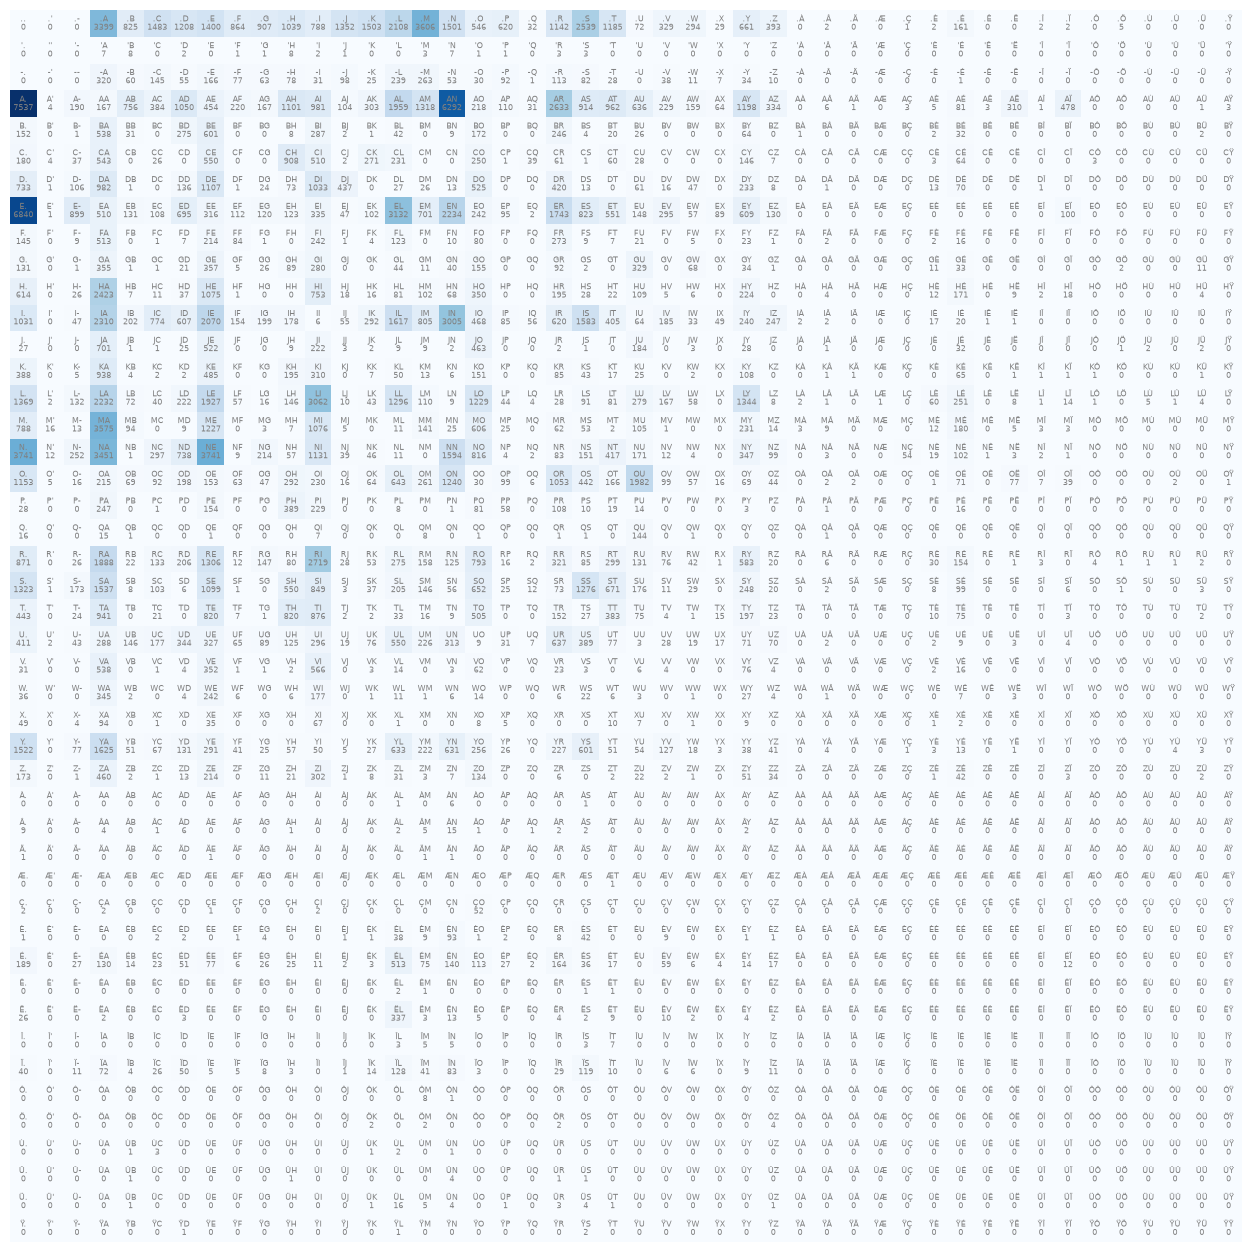

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(V):
    for j in range(V):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray', fontsize=6)
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray', fontsize=6)
plt.axis('off')
plt.show()


In [5]:
#计数变成条件概率，每一行除以每一行的和
P=N.float()
P/=P.sum(1,keepdims=True)
print(P.sum(1)[0].item()) #抽查第0行

1.0


In [6]:
#有了概率，怎么生成下一个字符，不能总选概率最大的，随机抽取。
def gen_name():
    out=[]
    ix=0
    while True:
        p=P[ix] #概率分布
        ix=torch.multinomial(p,num_samples=1,replacement=True).item() #replacement=True 表示每次抽样独立、可重复抽到同一字符
        out.append(itos[ix])
        if ix==0:
            break
    return ''.join(out)

for _ in range(10):
     print(gen_name())

HE-LÉLTCKERARE.
MAJA.
MANEVAIMIOLLONI.
ELIN.
MAE.
AS.
SE.
SÖKE.
TINDÉ.
ADJIYOULASSSAZÉMOUIA.


In [7]:
#生成的名字很差，是因为bigram只是看下一个字符可能是什么，完全不知道现在已经写到了第几个
'''
生成质量是定性感受，还要一个定量指标。对训练集里的每个 bigram，模型给出了一个概率；把这些概率乘起来就是"模型认为这批名字有多合理"（似然）。
但 20 多万个小于 1 的概率相乘，结果会下溢成 0。解决办法：取对数，把乘法变加法：
'''

sum_nll=0.0
n=0

for w in words:
    chs=['.']+list(w)+['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        prob=P[stoi[ch1],stoi[ch2]]
        sum_nll+= -torch.log(prob)
        n+=1

print(f"平均NLL: {(sum_nll/n).item():.4f}")

平均NLL: 2.4961


In [8]:
#神经网络版本
#造数据
xs,ys=[],[]
for w in words:
    chs=['.']+list(w)+['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])

xs=torch.tensor(xs)
ys=torch.tensor(ys)

print(xs.shape,ys.shape)

torch.Size([226325]) torch.Size([226325])


In [9]:
#为了方便神经网络的计算，也为了淡化不同整数之间的不必要的大小关系，我们用独热编码
#我感觉很像二进制那种状态压缩

import torch.nn.functional as F
xenc =F.one_hot(xs,num_classes=46).float()

import torch.nn as nn
W = torch.randn((46, 46), requires_grad=True)
opt = torch.optim.SGD([W], lr=50)
for k in range(100):
    logits = xenc @ W
    probs = F.softmax(logits, dim=1)
    loss = -probs[torch.arange(len(xs)), ys].log().mean() #负对数似然，probs[样本号，labels]的预测概率
    opt.zero_grad(); loss.backward(); opt.step()
    if(k==0 or (k+1)%10==0):
        print(f"k:{k+1},loss={loss}")

k:1,loss=4.307947635650635
k:10,loss=2.9886043071746826
k:20,loss=2.772901773452759
k:30,loss=2.690077066421509
k:40,loss=2.6451234817504883
k:50,loss=2.6165058612823486
k:60,loss=2.5966672897338867
k:70,loss=2.582221031188965
k:80,loss=2.5713329315185547
k:90,loss=2.5628886222839355
k:100,loss=2.5561716556549072


In [10]:
def gen_name_nn():
    out = []
    ix = 0
    while True:
        p = F.softmax(W[ix], dim=0)          # 用训练好的 W，不再用 P
        ix = torch.multinomial(p, num_samples=1, replacement=True).item()
        out.append(itos[ix])
        if ix == 0:
            break
    return ''.join(out)

for _ in range(10):
    print(gen_name_nn())

ONENN.
VJE.
MYN.
SI.
A.
ALYA.
VA.
K-UH.
YMARCQCAMAMIDA.
TOWELIA.
